# ✈ Predicting Flight Disruptions and Crew Fatigue ✈

### Core Idea

- In crew tracking, errors happen for example in a crew member accidentally getting assigned back-to-back flights with zero rest, or someone working too many flights in a single day.
- This project builds a simple Python tool that scans the flight data and instantly highlights these "unusual" schedules so a human controller can check them.

### Generate the Easy Synthetic Dataset

We are going to generate a synthetic dataset named easy_crew_anomalies.csv to simulate normal flight crew operations and inject a few clear anomalies. We uses pandas for data manipulation and numpy for numerical operations. First, we create 200 entries representing 'normal' crew schedules with 1-3 sectors per day and 10-18 hours of rest. Then, we explicitly inject 5 'anomalous' entries, characterized by an unusually high number of sectors (5-7) or critically low rest hours (under 8 hours). Finally, we combine these normal and anomalous datasets, labels the anomalies, and saves the complete dataset to a CSV file.

In [1]:
import pandas as pd
import numpy as np

# Set seed for identical results
np.random.seed(7)
num_normal_flights = 200

# 1. Create Normal Operations Data
# Most crew members fly 1 to 3 sectors a day, with 10 to 18 hours of rest
normal_sectors = np.random.randint(1, 4, size=num_normal_flights)
normal_rest = np.random.uniform(10.0, 18.0, size=num_normal_flights)

df_normal = pd.DataFrame({
    'crew_id': [f"CRW_{1000 + i}" for i in range(num_normal_flights)],
    'sectors_today': normal_sectors,
    'prior_rest_hours': normal_rest,
    'is_anomaly': 0  # Label 0 means completely normal schedule
})

# 2. Inject 5 Clear Anomalies (Errors the tracking team must catch!)
# These represent illegal schedules: huge sector counts or critically low rest hours
df_anomalies = pd.DataFrame({
    'crew_id': ['CRW_ERROR_1', 'CRW_ERROR_2', 'CRW_ERROR_3', 'CRW_ERROR_4', 'CRW_ERROR_5'],
    'sectors_today': [5, 6, 7, 5, 6],            # 5, 6, or 7 flights a day is extremely rare/illegal
    'prior_rest_hours': [3.5, 2.0, 12.0, 1.5, 4.0], # Rest under 8 hours violates safety rules
    'is_anomaly': 1  # Label 1 means an operational anomaly
})

# Combine into one final dataset
df_easy = pd.concat([df_normal, df_anomalies], ignore_index=True)

# Save to CSV
df_easy.to_csv("easy_crew_anomalies.csv", index=False)
print("✅ Easy dataset saved as 'easy_crew_anomalies.csv'")
print(df_easy.tail(10)) # Look at the bottom rows to see the errors we injected


✅ Easy dataset saved as 'easy_crew_anomalies.csv'
         crew_id  sectors_today  prior_rest_hours  is_anomaly
195     CRW_1195              3         10.070393           0
196     CRW_1196              1         15.392891           0
197     CRW_1197              3         11.325711           0
198     CRW_1198              1         12.743002           0
199     CRW_1199              1         17.622011           0
200  CRW_ERROR_1              5          3.500000           1
201  CRW_ERROR_2              6          2.000000           1
202  CRW_ERROR_3              7         12.000000           1
203  CRW_ERROR_4              5          1.500000           1
204  CRW_ERROR_5              6          4.000000           1


### Load and Explore the Dataset

Next, we are going to design for initial data loading and exploration. We begin by importing the pandas library, which is essential for working with dataframes. Then, we load the easy_crew_anomalies.csv file into a pandas DataFrame named df. After loading, we print the first few rows of the DataFrame using df.head() to give us a quick peek at the data's structure and content. Following that, df.info() is called to display a concise summary of the DataFrame, including the data types of each column and the count of non-null values, which helps in identifying missing data. Finally, df.describe() is used to generate descriptive statistics of the numerical columns in the DataFrame, such as count, mean, standard deviation, and quartiles, providing a statistical overview of the dataset.

In [2]:
import pandas as pd

df = pd.read_csv('easy_crew_anomalies.csv')

print("Dataset head:")
print(df.head())

print("\nDataset info:")
df.info()

print("\nDataset description:")
print(df.describe())

Dataset head:
    crew_id  sectors_today  prior_rest_hours  is_anomaly
0  CRW_1000              1         11.317733           0
1  CRW_1001              2         10.284230           0
2  CRW_1002              3         12.252271           0
3  CRW_1003              1         16.462967           0
4  CRW_1004              2         10.358130           0

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   crew_id           205 non-null    object 
 1   sectors_today     205 non-null    int64  
 2   prior_rest_hours  205 non-null    float64
 3   is_anomaly        205 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 6.5+ KB

Dataset description:
       sectors_today  prior_rest_hours  is_anomaly
count      205.00000        205.000000  205.000000
mean         2.02439         13.606901    0.024390
std   

### Visualize the Data

After that, we are going to generate a scatter plot to visualize the distribution of crew schedules, distinguishing between normal and anomalous entries. We start by importing matplotlib.pyplot for general plotting and seaborn for enhanced statistical visualizations. A figure is created with a specified size. The sns.scatterplot function then plots sectors_today on the x-axis and prior_rest_hours on the y-axis, using the is_anomaly column to color-code and style the points, making it easy to spot the anomalies. Normal entries (0) are blue circles, and anomalies (1) are red Xs. The plot is given a descriptive title and axis labels, a legend is added to clarify what the colors and markers represent, and a grid is included for better readability. Finally, plt.show() displays the generated plot.

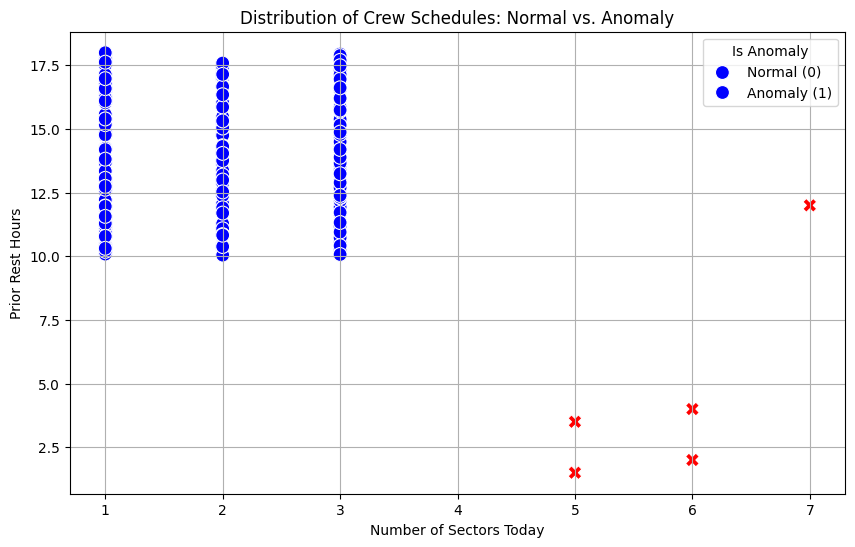

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='sectors_today',
    y='prior_rest_hours',
    hue='is_anomaly',
    style='is_anomaly',
    palette={0: 'blue', 1: 'red'},
    markers={0: 'o', 1: 'X'},
    s=100 # Adjust size of markers
)
plt.title('Distribution of Crew Schedules: Normal vs. Anomaly')
plt.xlabel('Number of Sectors Today')
plt.ylabel('Prior Rest Hours')
plt.legend(title='Is Anomaly', loc='upper right', labels=['Normal (0)', 'Anomaly (1)'])
plt.grid(True)
plt.show()

### Prepare Data for Machine Learning

The next one, we are preparing data dor machine learning, specifically for training and evaluating a model. We start by importing train_test_split from sklearn.model_selection, a function used to divide your dataset. First, we define the features (input data), represented by X, which are sectors_today and prior_rest_hours from your DataFrame. Then, we define the target (what you want to predict), represented by y, which is the is_anomaly column.

The core of this cell is the train_test_split function. We split the X and y data into training and testing sets. Here, test_size=0.3 means 30% of the data will be used for testing, and the remaining 70% for training. random_state=42 ensures that your splits are reproducible. Critically, stratify=y is used because the is_anomaly class is imbalanced. This parameter ensures that both the training and testing sets have approximately the same proportion of anomalies as the original dataset, which is vital for building a robust model. Finally, the code prints the shapes of the resulting training and testing sets for both features and targets, and then shows the distribution of anomalies in both the training and test sets using value_counts(normalize=True), confirming that the stratification worked as intended.

In [4]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['sectors_today', 'prior_rest_hours']]
y = df['is_anomaly']

# Split data into training and testing sets
# We use a stratify parameter to ensure that both training and test sets have
# approximately the same percentage of samples of each target class as the complete set.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of anomalies in training set:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of anomalies in test set:")
print(y_test.value_counts(normalize=True))

X_train shape: (143, 2)
X_test shape: (62, 2)
y_train shape: (143,)
y_test shape: (62,)

Distribution of anomalies in training set:
is_anomaly
0    0.979021
1    0.020979
Name: proportion, dtype: float64

Distribution of anomalies in test set:
is_anomaly
0    0.967742
1    0.032258
Name: proportion, dtype: float64


### Train a Logistic Regression Model

Moving on, we are focusing on training and evaluating a Logistic Regression model to detect anomalies. We start by improving necessary modules from sklearn for the model and evaluation metrics. The Logistic Regression model is initialized with random_state=42 for reproducibility and a class_weight parameter. The class_weight={0: 1, 1: 5} setting is crucial here because it assigns a higher weight to the minority class (anomalies, represented by 1). This tells the model to pay more attention to correctly identifying anomalies, which is common practice in imbalanced datasets like anomaly detection. The model is then trained using the X_train and y_train data. After training, it makes predictions on the test set (X_test) to get both class predictions (y_pred) and probability scores (y_proba). Finally, the model's performance is evaluated and printed using a classification_report, a confusion_matrix, and the roc_auc_score.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize the Logistic Regression model
# We'll set a higher class_weight for the minority class (anomalies) to help the model learn them
model = LogisticRegression(random_state=42, class_weight={0: 1, 1: 5}) # Anomaly (1) is weighted 5 times more

# Train the model
model.fit(X_train, y_train)

print("✅ Logistic Regression model trained successfully.")

# Make predictions on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nROC AUC Score:", roc_auc_score(y_test, y_proba))

✅ Logistic Regression model trained successfully.

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       1.00      0.50      0.67         2

    accuracy                           0.98        62
   macro avg       0.99      0.75      0.83        62
weighted avg       0.98      0.98      0.98        62


Confusion Matrix:
[[60  0]
 [ 1  1]]

ROC AUC Score: 1.0


The model performs exceptionally well at identifying normal cases and has no false positives when predicting anomalies (precision of 1.00 for class 1). However, it currently misses one out of two anomalies (recall of 0.50 for class 1). The high ROC AUC score suggests that the model has learned good underlying distinctions between the classes, and we might be able to improve the recall for anomalies by adjusting the classification threshold. For anomaly detection, catching all anomalies (high recall for class 1) is more critical than having perfect precision.